## Extract value at point from raster

In [1]:
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from rasterio.plot import show
proj_dir = "D:/r/KenyaDSM"
soil_path = proj_dir + '/' + "data/soil"

### Extract from shapefile

EPSG:4326


<Axes: >

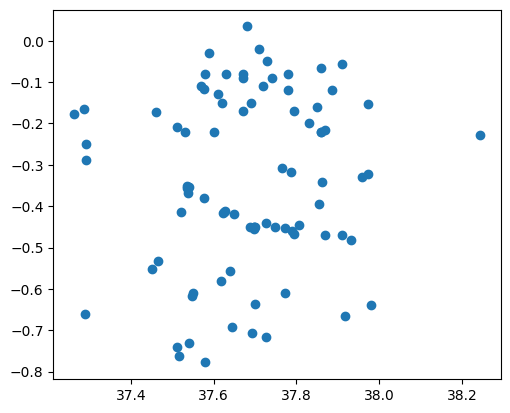

In [2]:
# read from soilprofiles shapefile
points = gpd.read_file(soil_path + '/' + 'ke_sp/sample/region_sp.shp')
print(points.crs)
points.plot()

In [3]:
## retrieve raster 
mg_map = rasterio.open(soil_path+'/'+'models/mgsvm_pred.tif')
k_map = rasterio.open(soil_path+'/'+'models/ksvm_pred.tif')
print(mg_map.crs)
print(k_map.crs)

EPSG:4326
EPSG:4326


<Axes: >

c:\Users\vikir\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\colors.py:732: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


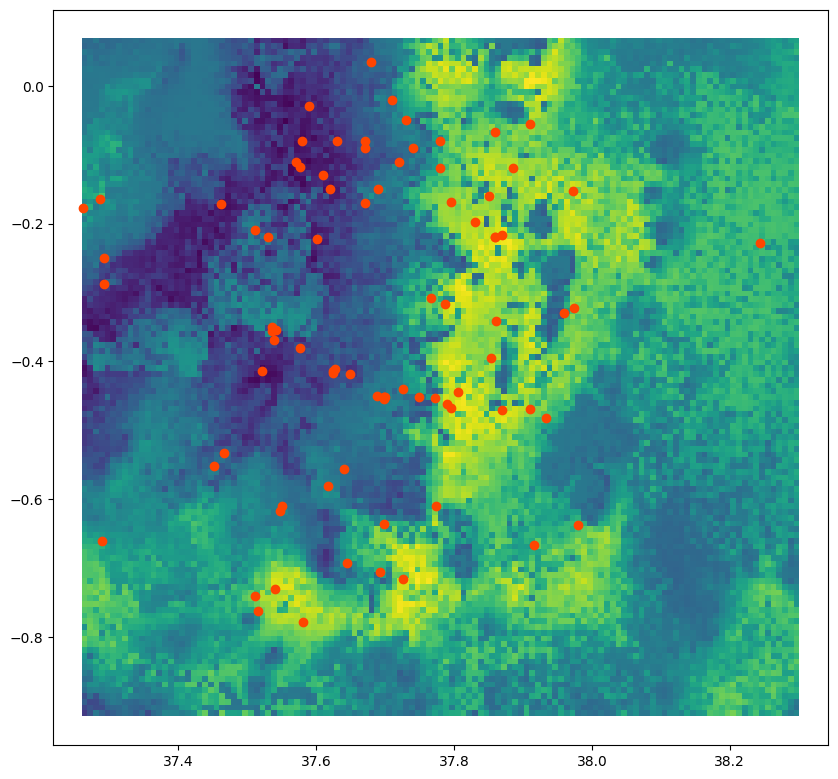

In [4]:
## plot point distribution of mg map
fig, ax = plt.subplots(figsize=(10,10))
points.plot(ax=ax, color="orangered")
show(mg_map, ax=ax)

<Axes: >

c:\Users\vikir\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\image.py:499: RuntimeWarning: overflow encountered in divide
  A_scaled /= ((a_max - a_min) / frac)


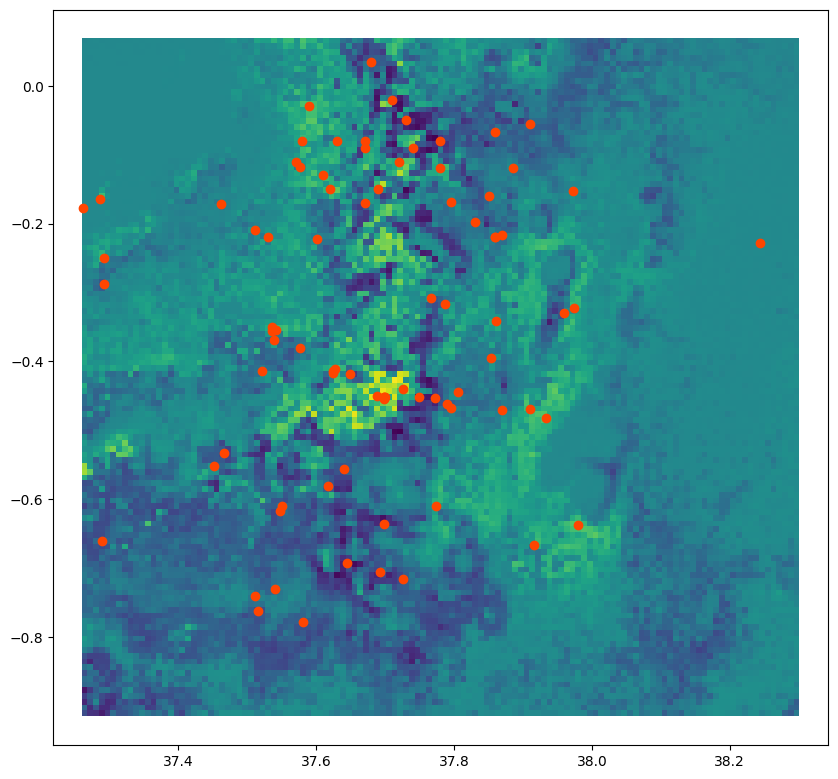

In [5]:
## plot point distribution of k map
fig, ax = plt.subplots(figsize=(10,10))
points.plot(ax=ax, color="orangered")
show(k_map, ax=ax)

In [6]:
# extract xy from point geometry
for point in points['geometry']:
    print(point.xy[0][0], point.xy[1][0])

37.79482 -0.1688
37.67 -0.08
37.57632 -0.11767
37.60053 -0.22186
37.88503 -0.11952
37.85934 -0.06698
37.9737 -0.322
37.7953 -0.4671
37.87 -0.47
37.8614 -0.3419
37.90994 -0.46947
37.9333 -0.4821
37.2888 -0.661
37.5118 -0.7398
37.5475 -0.6176
37.6403 -0.5565
37.6176 -0.5814
37.7262 -0.7159
37.699 -0.6357
37.6448 -0.6923
37.9796 -0.638
37.7737 -0.6097
37.5158 -0.7624
37.28604 -0.1644
37.2617 -0.1779
37.2918 -0.25
37.2919 -0.28828
37.461111 -0.172222
37.511111 -0.209722
37.538889 -0.354167
37.541667 -0.354167
37.536111 -0.355556
37.576389 -0.380556
37.627778 -0.411111
37.625 -0.413889
37.623611 -0.416667
37.7 -0.451389
37.698611 -0.451389
37.698611 -0.452778
37.451667 -0.552222
37.772222 -0.452778
37.790278 -0.461111
37.805556 -0.444444
37.972222 -0.152222
38.244444 -0.227778
37.466667 -0.533333
37.916667 -0.666667
37.786111 -0.316667
37.68 0.0344
37.71 -0.02
37.67 -0.09
37.74 -0.09
37.72 -0.11
37.69 -0.15
37.63 -0.08
37.58 -0.08
37.61 -0.13
37.62 -0.15
37.67 -0.17
37.53 -0.22
37.59 -0.03


In [7]:
# get point value from rasters
for point in points['geometry']:
    x = point.xy[0][0]
    y = point.xy[1][0]
    # this for interactive map to raster
    mg_row,mg_col = mg_map.index(x,y)
    k_row, k_col = k_map.index(x, y)
    print("ExMg value on long/lat [",x, y,"]:",mg_map.read(1)[mg_row, mg_col])
    print("ExK value on long/lat [",x, y,"]:",k_map.read(1)[k_row, k_col],"\n")

ExMg value on long/lat [ 37.79482 -0.1688 ]: 3.0281034
ExK value on long/lat [ 37.79482 -0.1688 ]: 0.35457173 

ExMg value on long/lat [ 37.67 -0.08 ]: 1.4279459
ExK value on long/lat [ 37.67 -0.08 ]: 0.32629535 

ExMg value on long/lat [ 37.57632 -0.11767 ]: 0.582035
ExK value on long/lat [ 37.57632 -0.11767 ]: 0.3510022 

ExMg value on long/lat [ 37.60053 -0.22186 ]: 0.7033082
ExK value on long/lat [ 37.60053 -0.22186 ]: 0.35167524 

ExMg value on long/lat [ 37.88503 -0.11952 ]: 3.2707047
ExK value on long/lat [ 37.88503 -0.11952 ]: 0.3569902 

ExMg value on long/lat [ 37.85934 -0.06698 ]: 2.680142
ExK value on long/lat [ 37.85934 -0.06698 ]: 0.32971168 

ExMg value on long/lat [ 37.9737 -0.322 ]: 3.1334012
ExK value on long/lat [ 37.9737 -0.322 ]: 0.39916846 

ExMg value on long/lat [ 37.7953 -0.4671 ]: 3.401671
ExK value on long/lat [ 37.7953 -0.4671 ]: 0.34753045 

ExMg value on long/lat [ 37.87 -0.47 ]: 3.4301996
ExK value on long/lat [ 37.87 -0.47 ]: 0.35527813 

ExMg value on l